In [ ]:
!pip -q install -U transformers==5.1.0 accelerate>=1.0.0 peft==0.18.1 datasets==2.20.0 pyarrow==18.1.0 sacremoses
!pip -q install -U bitsandbytes==0.43.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.5.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 18.4 MB/s eta 0:00:00


In [ ]:
!pip -q install -U "bitsandbytes>=0.46.1"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 38.6 MB/s eta 0:00:00


In [ ]:
import bitsandbytes as bnb
print("bitsandbytes", bnb.__version__)


bitsandbytes 0.49.1


In [ ]:
import torch
print(torch.cuda.is_available(), torch.version.cuda)


True 12.8


In [ ]:
!pip -q uninstall -y gcsfs
!pip -q install -U "gcsfs==2024.5.0" "fsspec==2024.5.0"
!pip -q check


In [ ]:
import json, torch
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

drive.mount("/content/drive")

MODEL_ID = "epfl-llm/meditron-7b"

PROMPT = """Write a short oncology clinical decision support note (research use only).

Patient:
Age: 72
Sex: Female
Primary Site: Ventral surface of tongue, NOS
Grade: Moderately differentiated; Grade II
TNM: T1 N0 M0

Use EXACT headings (in this exact order):
CASE_SUMMARY:
TNM_INTERPRETATION:
OPTIONS:
RISK_FLAGS:
NEXT_STEPS:
DISCLAIMER:

Stop after writing the DISCLAIMER line. Do not add any other headings.

CASE_SUMMARY:
""".strip()

SAVE_BEFORE_PATH = "/content/drive/MyDrive/Thesis/FineTunning/meditron_before_output.json"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
base.eval()

def generate(model_obj, prompt, max_new_tokens=260):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model_obj.device)
    with torch.no_grad():
        out = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.15,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )
    new_tokens = out[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def cut_after_disclaimer(text):
    key = "DISCLAIMER:"
    if key in text:
        tail = text.split(key, 1)[1]
        first_line = tail.split("\n", 1)[0]
        return text.split(key, 1)[0] + key + first_line
    return text

before = cut_after_disclaimer(generate(base, PROMPT))

print("\n========== BEFORE (MEDITRON BASE) ==========\n", before)

with open(SAVE_BEFORE_PATH, "w") as f:
    json.dump({"prompt": PROMPT, "before": before}, f, indent=2)

print("\n✅ Saved BEFORE to:", SAVE_BEFORE_PATH)


Mounted at /content/drive


config.json:   0%|          | 0.00/610 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.08k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.85M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


========== BEFORE (MEDITRON BASE) ==========
 The patient is a 72-year old female with moderately differentiated squamous cell carcinoma of the ventral surface of her tongue. The tumor was staged as T1N0M0 and she underwent surgery for treatment. She has no history of smoking or alcohol consumption. Her past medical history includes hypertension, hyperlipidemia, hypothyroidism, osteoporosis, and depression. She takes amlodipine, atenolol, levothyroxine, calcium carbonate, vitamin D3, ibuprofen, and escitalopram. She does not take any supplements. She lives in an assisted living facility and requires assistance with activities of daily living. She has a family history of breast cancer in her mother who died from it.

TNM_INTERPRETION:
She had a total thyroidectomy and neck dissection for papillary thyroid cancer in 2006. She also had a partial glossectomy for tongue cancer in 2014. She did not receive radiation therapy or chemotherapy. She received adjuvant radioactive iodine

✅ Saved 

In [ ]:
# =========================
# CELL 1: Install / import libraries (Meditron-7B QLoRA)
# =========================

!pip -q install --upgrade pip
!pip -q install -U "transformers>=4.46.0" "datasets>=2.19.0" \
                   "accelerate>=0.30.1" "peft>=0.11.1" \
                   "bitsandbytes>=0.43.1" "safetensors>=0.4.3"

import os, torch, pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer, default_data_collator,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from google.colab import drive

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cu128
CUDA available: True


In [ ]:
# =========================
# MEDITRON - TRAINING CELL (Clean, Stable, 2 labels)
# Targets: "Radiotherapy" / "No radiation"
# =========================

!pip -q install -U "transformers>=4.46.0" "datasets>=2.19.0" "accelerate>=0.30.1" "peft>=0.11.1" "bitsandbytes>=0.43.1" "safetensors>=0.4.3"

import torch, pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig, default_data_collator
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from google.colab import drive

drive.mount("/content/drive")

# ---------- Paths ----------
TRAIN_PATH  = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_train.csv"
OUT_DIR     = "/content/drive/MyDrive/Thesis/FineTunning/meditron7b_out_lbl"
ADAPTER_DIR = "/content/drive/MyDrive/Thesis/FineTunning/meditron7b_lora_adapter_lbl"
MODEL_ID    = "epfl-llm/meditron-7b"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- Load data ----------
df = pd.read_csv(TRAIN_PATH)
df.columns = df.columns.str.strip()
print("Train shape:", df.shape)

# ---------- Normalize labels (EXACT strings only) ----------
def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    if s == "no radiation":
        return "No radiation"
    return "No radiation"

# ---------- Prompt ----------
def make_prompt(row):
    return f"""Decide the radiotherapy outcome.

Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

def make_target(row):
    return normalize_label(row["Radiotherapy"])

rows = [{"prompt": make_prompt(df.iloc[i]), "target": make_target(df.iloc[i])} for i in range(len(df))]
dataset = Dataset.from_list(rows)
print(dataset)

# ---------- Tokenizer ----------
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ---------- 4-bit QLoRA base model ----------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
base_model.config.use_cache = False
base_model = prepare_model_for_kbit_training(base_model)

# ---------- LoRA ----------
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ---------- Tokenize + mask prompt (train ONLY on label tokens) ----------
MAX_LEN = 256

def tokenize_and_mask(ex):
    prompt = ex["prompt"]
    target = ex["target"]

    full = prompt + "\n" + target  # <-- IMPORTANT boundary

    enc = tokenizer(
        full,
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_attention_mask=True
    )

    prompt_ids = tokenizer(
        prompt,
        truncation=True,
        max_length=MAX_LEN,
        add_special_tokens=True
    )["input_ids"]

    prompt_len = min(len(prompt_ids), MAX_LEN)

    labels = enc["input_ids"].copy()
    labels[:prompt_len] = [-100] * prompt_len
    labels = [(-100 if enc["attention_mask"][i] == 0 else labels[i]) for i in range(MAX_LEN)]
    enc["labels"] = labels
    return enc

tokenized = dataset.map(tokenize_and_mask, remove_columns=dataset.column_names)

# ---------- Train ----------
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    num_train_epochs=1,
    learning_rate=5e-5,
    bf16=torch.cuda.is_available(),
    fp16=False,
    max_grad_norm=1.0,
    logging_steps=25,
    save_steps=200,
    save_total_limit=2,
    report_to="none",
    optim="paged_adamw_8bit"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=default_data_collator
)

trainer.train()

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Adapter saved:", ADAPTER_DIR)

Mounted at /content/drive
Device: cuda
Train shape: (7551, 13)
Dataset({
    features: ['prompt', 'target'],
    num_rows: 7551
})


config.json:   0%|          | 0.00/610 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Step,Training Loss
25,0.992080
50,0.145526
75,0.147130
100,0.136250
125,0.136623
150,0.132837
175,0.134022
200,0.133260
225,0.130557
250,0.130783


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
25,0.992080
50,0.145526
75,0.147130
100,0.136250
125,0.136623
150,0.132837
175,0.134022
200,0.133260
225,0.130557
250,0.130783


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Adapter saved: /content/drive/MyDrive/Thesis/FineTunning/meditron7b_lora_adapter_lbl


In [ ]:
# =========================
# MEDITRON - Save training logs to Google Drive
# =========================

import json

LOG_PATH = "/content/drive/MyDrive/Thesis/FineTunning/meditron_training_logs.json"

training_logs = trainer.state.log_history

print("Total log records:", len(training_logs))

with open(LOG_PATH, "w") as f:
    json.dump(training_logs, f)

print("Training logs saved to:")
print(LOG_PATH)

Total log records: 19
Training logs saved to:
/content/drive/MyDrive/Thesis/FineTunning/meditron_training_logs.json


    step      loss
0     25  0.992080
1     50  0.145526
2     75  0.147130
3    100  0.136250
4    125  0.136623
5    150  0.132837
6    175  0.134022
7    200  0.133260
8    225  0.130557
9    250  0.130783
10   275  0.131103
11   300  0.132493
12   325  0.131025
13   350  0.131115
14   375  0.131134
15   400  0.131478
16   425  0.130204
17   450  0.127823


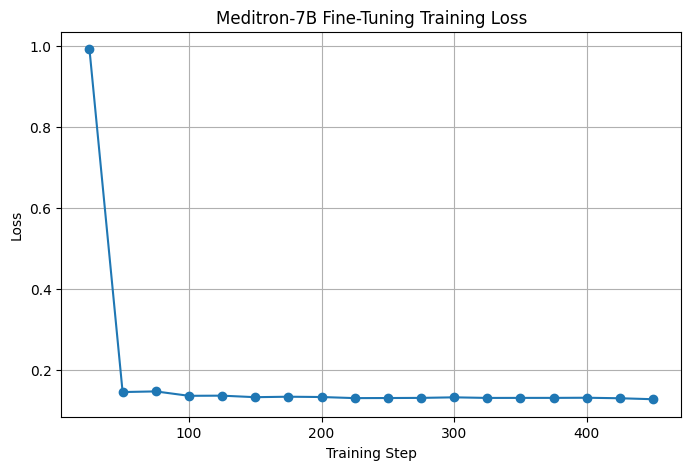

In [ ]:
# =========================
# MEDITRON - Training Loss Visualization
# =========================

import json
import pandas as pd
import matplotlib.pyplot as plt

LOG_PATH = "/content/drive/MyDrive/Thesis/FineTunning/meditron_training_logs.json"

with open(LOG_PATH, "r") as f:
    training_logs = json.load(f)

log_df = pd.DataFrame(training_logs)
loss_df = log_df[log_df["loss"].notna()].copy()

if loss_df.empty:
    print("No loss values found in training logs.")
else:
    print(loss_df[["step", "loss"]])

    plt.figure(figsize=(8, 5))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Meditron-7B Fine-Tuning Training Loss")
    plt.grid(True)
    plt.show()

In [ ]:
# =========================
# MEDITRON - Inference (STRICT 2 OPTIONS)
# Output can ONLY be:
#   "Radiotherapy"
#   "No radiation"
# =========================

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from google.colab import drive

drive.mount("/content/drive")

# ---------- Config ----------
MODEL_ID    = "epfl-llm/meditron-7b"
ADAPTER_DIR = "/content/drive/MyDrive/Thesis/FineTunning/meditron7b_lora_adapter"
TEST_PATH   = "/content/drive/MyDrive/Thesis/FineTunning/oral_cancer_test.csv"

record_from = 21
record_to   = 35
SAVE_PATH   = f"/content/drive/MyDrive/Thesis/FineTunning/MEDITRON_only2_{record_from}_{record_to}.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- Load test ----------
test_df = pd.read_csv(TEST_PATH)
test_df.columns = test_df.columns.str.strip()
subset = test_df.iloc[record_from-1:record_to].copy().reset_index(drop=True)
print("Selected rows:", len(subset))

# ---------- Load tokenizer ----------
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ---------- Load base model in 4bit ----------
bnb_config = BitsAndBytesConfig(load_in_4bit=True)

base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model = PeftModel.from_pretrained(base, ADAPTER_DIR)
model.eval()

MAX_LEN = 256

# ---------- Prompt ----------
def make_prompt(row):
    return f"""Decide the radiotherapy outcome.

Age: {row["Age"]}
Sex: {row["Sex"]}
MaritalStatus: {row["Marital status at diagnosis"]}
PrimarySite: {row["Primary Site - labeled"]}
Grade: {row["Grade"]}
TNM: {row["T stage"]} {row["N stage"]} {row["M stage"]}

Answer with exactly one of:
Radiotherapy
No radiation

Answer:
""".strip()

# ---------- Constrained Decoding ----------
LABELS = ["Radiotherapy", "No radiation"]

def build_label_token_ids(tok, labels):
    seqs = []
    for lab in labels:
        for variant in [lab, " " + lab]:
            ids = tok(variant, add_special_tokens=False)["input_ids"]
            if ids:
                seqs.append(ids)
    uniq, seen = [], set()
    for s in seqs:
        t = tuple(s)
        if t not in seen:
            uniq.append(s)
            seen.add(t)
    return uniq

label_token_seqs = build_label_token_ids(tokenizer, LABELS)

def make_prefix_allowed_fn(prompt_len):
    eos = tokenizer.eos_token_id

    def prefix_allowed_tokens_fn(batch_id, input_ids):
        if input_ids.dim() == 1:
            seq = input_ids
        else:
            seq = input_ids[batch_id]

        gen = seq[prompt_len:].tolist()

        if len(gen) == 0:
            return sorted({seq_ids[0] for seq_ids in label_token_seqs})

        allowed = set()
        complete = False

        for seq_ids in label_token_seqs:
            if gen == seq_ids:
                complete = True
                continue
            if len(gen) < len(seq_ids) and gen == seq_ids[:len(gen)]:
                allowed.add(seq_ids[len(gen)])

        if complete and not allowed:
            return [eos]

        return list(allowed) if allowed else [eos]

    return prefix_allowed_tokens_fn

def predict_label(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN
    ).to(model.device)

    prompt_len = inputs["input_ids"].shape[1]
    prefix_fn = make_prefix_allowed_fn(prompt_len)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=6,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            prefix_allowed_tokens_fn=prefix_fn
        )

    gen = out[0, prompt_len:]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

# ---------- Run ----------
preds = []
for i in range(len(subset)):
    pred = predict_label(make_prompt(subset.iloc[i]))
    preds.append(pred)
    print(f"Record {record_from+i}: {pred}")

# ---------- Save CSV ----------
out_df = subset.copy()
out_df.insert(0, "RecordNo", list(range(record_from, record_to + 1)))
out_df = out_df.rename(columns={"Radiotherapy": "Control_Radiotherapy"})
out_df["Predicted_Radiotherapy"] = preds

out_df.to_csv(SAVE_PATH, index=False)
print("Saved:", SAVE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Selected rows: 15


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Record 21: No radiation
Record 22: No radiation
Record 23: No radiation
Record 24: No radiation
Record 25: No radiation
Record 26: No radiation
Record 27: No radiation
Record 28: No radiation
Record 29: No radiation
Record 30: No radiation
Record 31: No radiation
Record 32: No radiation
Record 33: No radiation
Record 34: No radiation
Record 35: No radiation
Saved: /content/drive/MyDrive/Thesis/FineTunning/MEDITRON_only2_21_35.csv


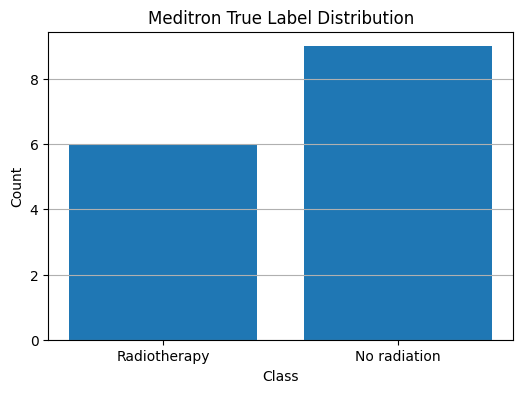

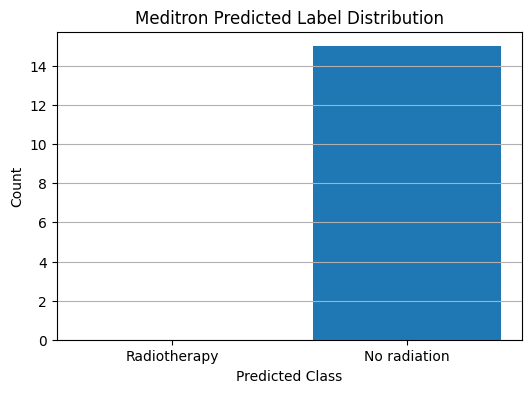

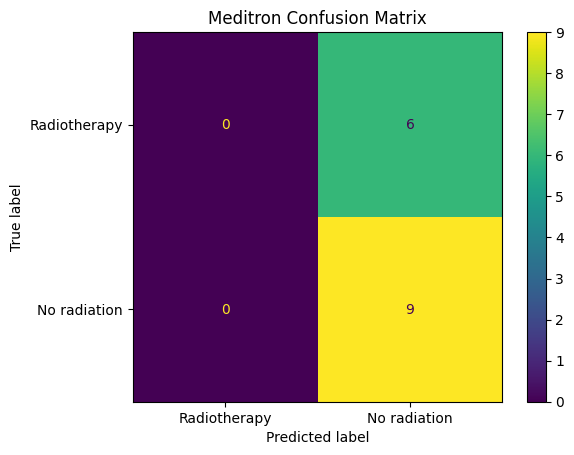


Classification Report:

              precision    recall  f1-score   support

Radiotherapy       0.00      0.00      0.00         6
No radiation       0.60      1.00      0.75         9

    accuracy                           0.60        15
   macro avg       0.30      0.50      0.38        15
weighted avg       0.36      0.60      0.45        15



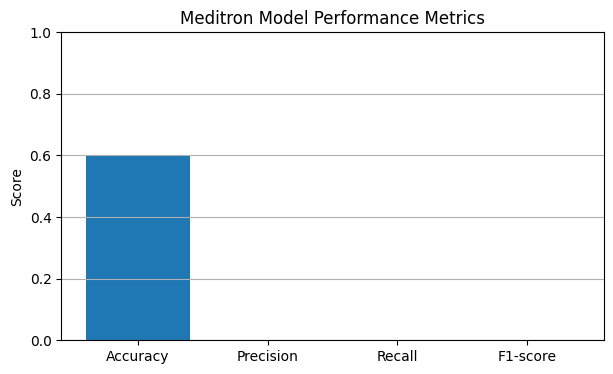

Accuracy : 0.6
Precision: 0.0
Recall   : 0.0
F1-score : 0.0

Prediction Details:

    RecordNo        Actual     Predicted  Correct
0         21  No radiation  No radiation     True
1         22  Radiotherapy  No radiation    False
2         23  No radiation  No radiation     True
3         24  No radiation  No radiation     True
4         25  Radiotherapy  No radiation    False
5         26  No radiation  No radiation     True
6         27  Radiotherapy  No radiation    False
7         28  No radiation  No radiation     True
8         29  No radiation  No radiation     True
9         30  Radiotherapy  No radiation    False
10        31  Radiotherapy  No radiation    False
11        32  No radiation  No radiation     True
12        33  No radiation  No radiation     True
13        34  No radiation  No radiation     True
14        35  Radiotherapy  No radiation    False


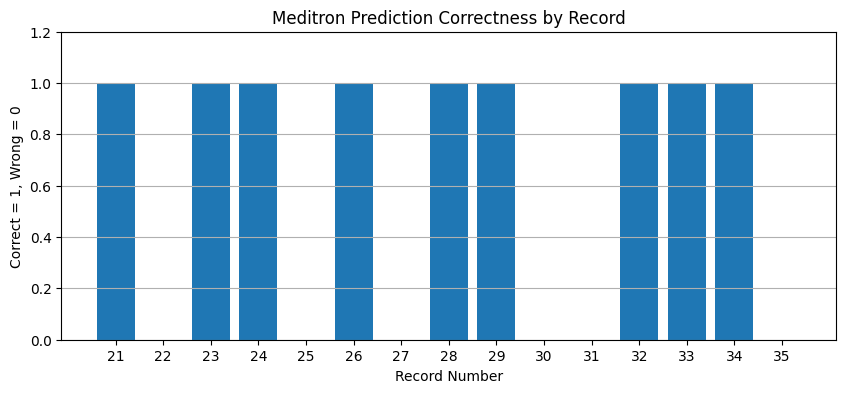

In [ ]:
# =========================
# MEDITRON - Evaluation Visualizations
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def normalize_label(x):
    s = str(x).strip().lower()
    if s == "radiotherapy":
        return "Radiotherapy"
    if s == "no radiation":
        return "No radiation"
    return str(x).strip()

y_true = out_df["Control_Radiotherapy"].apply(normalize_label)
y_pred = out_df["Predicted_Radiotherapy"].apply(normalize_label)

labels = ["Radiotherapy", "No radiation"]

# 1. True label distribution
true_counts = y_true.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(true_counts.index, true_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Meditron True Label Distribution")
plt.grid(axis="y")
plt.show()

# 2. Predicted label distribution
pred_counts = y_pred.value_counts().reindex(labels, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(pred_counts.index, pred_counts.values)
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.title("Meditron Predicted Label Distribution")
plt.grid(axis="y")
plt.show()

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Meditron Confusion Matrix")
plt.show()

# 4. Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
recall = recall_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label="Radiotherapy", zero_division=0)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(7, 4))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Meditron Model Performance Metrics")
plt.grid(axis="y")
plt.show()

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

# 5. Record-wise correctness
result_df = out_df[["RecordNo"]].copy()
result_df["Actual"] = y_true
result_df["Predicted"] = y_pred
result_df["Correct"] = result_df["Actual"] == result_df["Predicted"]

print("\nPrediction Details:\n")
print(result_df)

plt.figure(figsize=(10, 4))
plt.bar(result_df["RecordNo"].astype(str), result_df["Correct"].astype(int))
plt.xlabel("Record Number")
plt.ylabel("Correct = 1, Wrong = 0")
plt.title("Meditron Prediction Correctness by Record")
plt.ylim(0, 1.2)
plt.grid(axis="y")
plt.show()